# Visão Computacional - Detecção de Face
anaconda ambiente 

conda env list

conda activate pycaret-env


## Detecção de faces

In [1]:
#!pip install opencv-python


In [3]:
import cv2 # OpenCV 
#utiliza linguagem em C

## leitura da imagem, queremos detectar a imagem das pessoas. O algoritmo detecta mais faces que estão totalmente de frente.

In [4]:
# imagem carregada no sistema
imagem = cv2.imread('workplace-1245776_1920.jpg')

In [5]:
#cv2.imshow(imagem)
# google colab
#from google.colab.patches import cv2_imshow
# cv2_imshow(imagem)
# comand ctrl + : comentar

In [6]:
#!pip install numpy==1.26.4

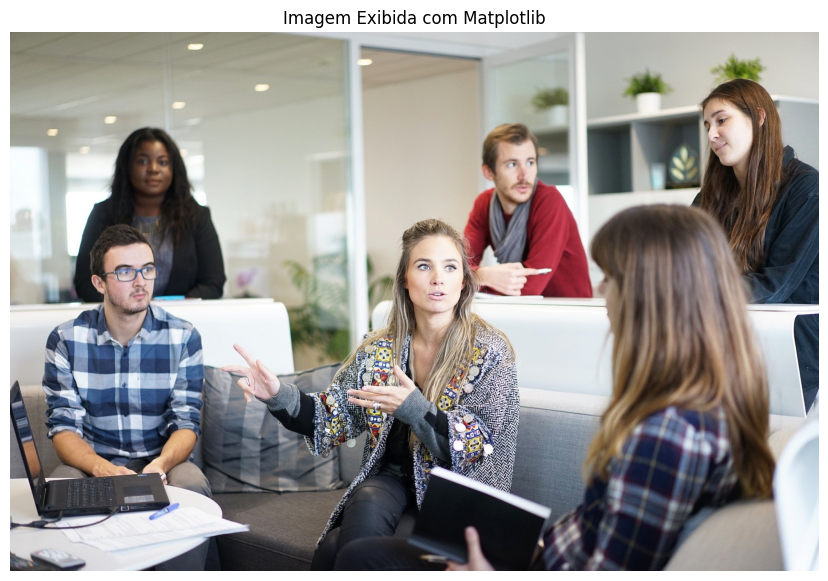

In [7]:
import cv2
import matplotlib.pyplot as plt
# Nota: cv2 lê a imagem em BGR; o Matplotlib espera RGB.

# 2. Converter de BGR para RGB para cores corretas no Matplotlib
imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
fig = plt.figure(figsize=(12, 7)) 

# 3. Exibir com Matplotlib
plt.imshow(imagem_rgb)
plt.title("Imagem Exibida com Matplotlib")
plt.axis('off') # Remove os eixos
plt.show()

#### carregar um arquivo xml agora

# o arquivo já vem treinado para o sistema

o arquivo treinado já localiza as faces para indicar e detectar nas novas fotos: haarcascade_frontalface_default.xml

In [8]:
# carregando o nosso detector de face 
detector_face = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

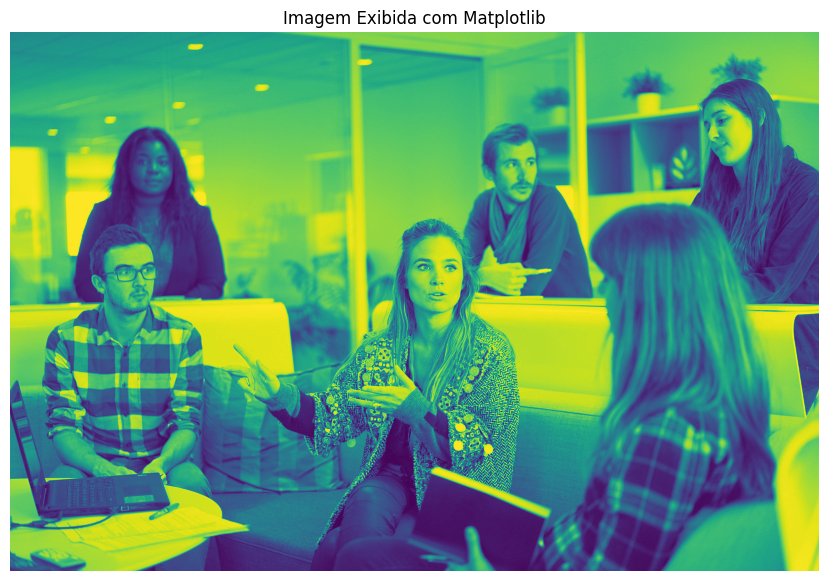

In [9]:
# precisamos converter a imagem para a escala cinza
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
#cv2_imshow(imagem_cinza)

fig = plt.figure(figsize=(12, 7)) 

# 3. Exibir com Matplotlib
plt.imshow(imagem_cinza)
plt.title("Imagem Exibida com Matplotlib")
plt.axis('off') # Remove os eixos
plt.show()

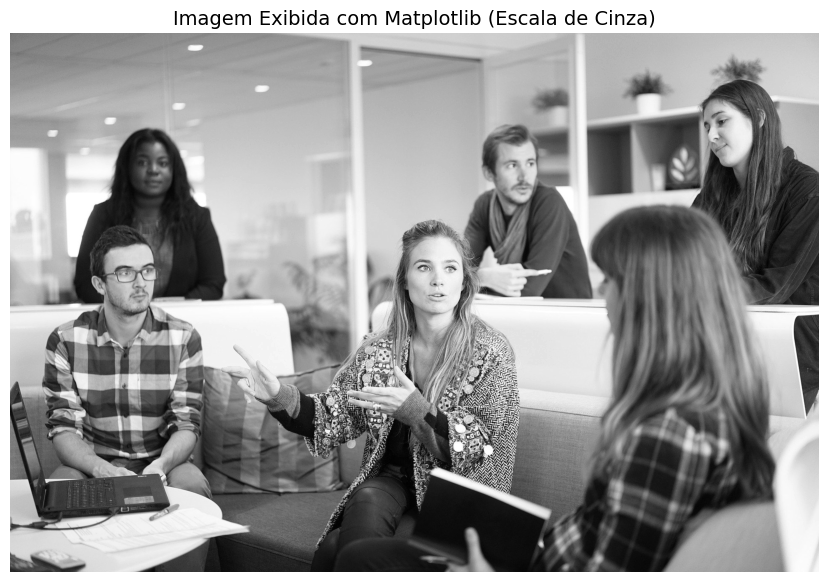

In [10]:
# Define o tamanho da figura
fig = plt.figure(figsize=(12, 7)) 

# 3. Exibir com Matplotlib, definindo o colormap para tons de cinza
plt.imshow(imagem_cinza, cmap='gray') # <--- CORREÇÃO AQUI

plt.title("Imagem Exibida com Matplotlib (Escala de Cinza)", fontsize=14)
plt.axis('off') # Remove os eixos
plt.show()

In [11]:

# aplicar o detector cascade, com a função => detectMultiScale
deteccoes = detector_face.detectMultiScale(imagem_cinza)

#deteccoes = detector_face.detectMultiScale(imagem_cinza, scaleFactor=1.3, minSize=(30,30))

## observar os resultados

# indica as matrizes das posições 

In [12]:
deteccoes

array([[1639,  159,  141,  141],
       [ 284,  263,  113,  113],
       [1148,  261,  129,  129],
       [ 928,  488,  172,  172],
       [ 229,  509,  142,  142],
       [ 103,  784,   56,   56],
       [  44,  919,   30,   30]], dtype=int32)

In [13]:
print(f'foi detectado as {len(deteccoes)} faces') # análise pelos pixes.  x y 

foi detectado as 7 faces


Coluna 0 :	Coordenada X (ou Posição Horizontal)	Onde o pixel está localizado no eixo X da imagem.

Coluna 1 :	Coordenada Y (ou Posição Vertical)	Onde o pixel está localizado no eixo Y da imagem.

Coluna 2 :	Valor do Pixel (Intensidade/Cor)	O valor numérico (0 a 255) que representa a intensidade do brilho.

Coluna 3 :	Valor Redundante (ou Dimensão Extra)	Geralmente, é um valor repetido da Coluna 2 em imagens de escala de cinza, ou pode ser uma métrica extra (como o raio/tamanho do ponto).



(x, y, l, a)

posição x, posição y, l largura, a altura. 

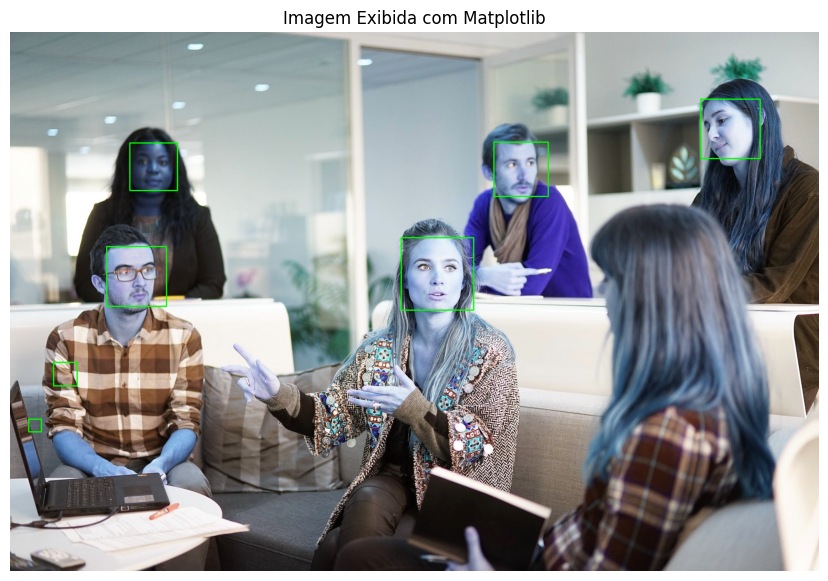

In [14]:
# aeessando cada uma das posições
for (x, y, l, a) in deteccoes:
  #print(x, y, l, a)
  cv2.rectangle(imagem, (x, y), (x + l, y + a), (0,255,0), 2)
#cv2_imshow(imagem)

fig = plt.figure(figsize=(12, 7)) 
# detectar na imagem original
# 3. Exibir com Matplotlib
plt.imshow(imagem)
plt.title("Imagem Exibida com Matplotlib")
plt.axis('off') # Remove os eixos
plt.show()

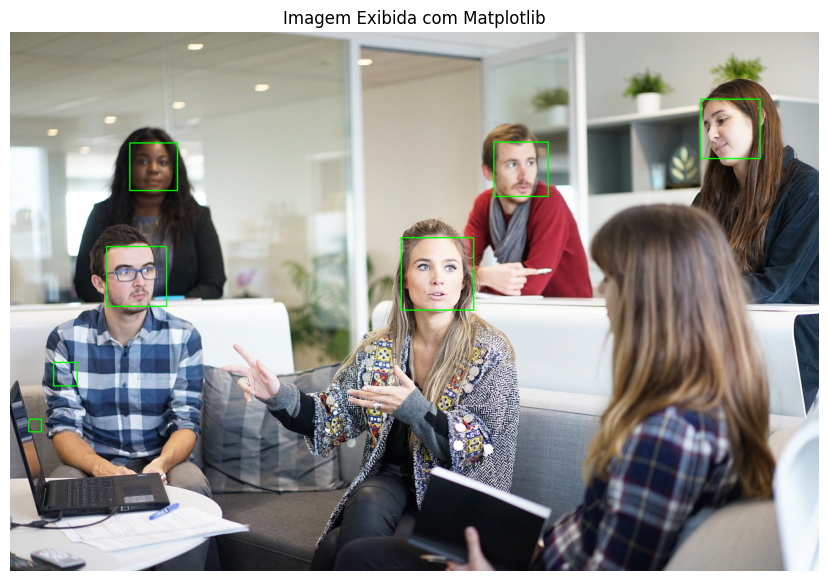

In [15]:
# aeessando cada uma das posições
for (x, y, l, a) in deteccoes:
  #print(x, y, l, a)
  cv2.rectangle(imagem_rgb, (x, y), (x + l, y + a), (0,255,0), 2)
#cv2_imshow(imagem)

fig = plt.figure(figsize=(12, 7)) 
# detectar na imagem original
# 3. Exibir com Matplotlib
plt.imshow(imagem_rgb)
plt.title("Imagem Exibida com Matplotlib")
plt.axis('off') # Remove os eixos
plt.show()

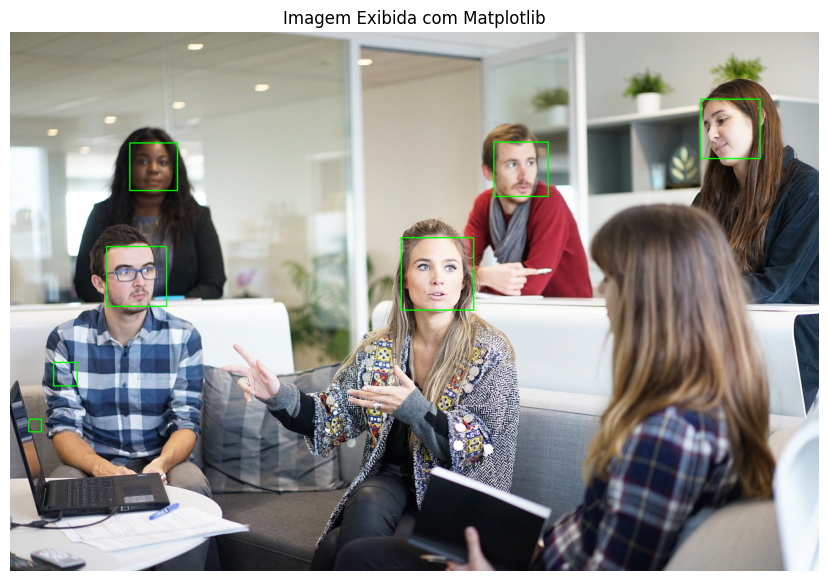

In [16]:
# aeessando cada uma das posições
for (x, y, l, a) in deteccoes:
  #print(x, y, l, a)
  cv2.rectangle(imagem_rgb, (x, y), (x , y ), (0,255,0), 2)
#cv2_imshow(imagem)

fig = plt.figure(figsize=(12, 7)) 
# detectar na imagem original
# 3. Exibir com Matplotlib
plt.imshow(imagem_rgb)
plt.title("Imagem Exibida com Matplotlib")
plt.axis('off') # Remove os eixos
plt.show()

# houve falsas detecções nas roupas

vamos configurar os novos parâmetros 

In [17]:
# imagem carregada no sistema
imagem_2 = cv2.imread('workplace-1245776_1920.jpg')

In [18]:
# precisamos converter a imagem para a escala cinza
imagem_cinza_2 = cv2.cvtColor(imagem_2, cv2.COLOR_BGR2GRAY)

In [19]:
# o valor scaleFactor dá um zoom na imagem, para melhor detecção; Aumentamos a escala da imamgem para detectar a face correta. 

# minSize=(30,30) tamanho mínimo de uma face para fazer uma detecção
#para não pegar as faces pequenas

deteccoes2 = detector_face.detectMultiScale(imagem_cinza_2, scaleFactor=1.3, minSize=(30,30))

In [20]:
deteccoes2

array([[ 284,  262,  114,  114],
       [1635,  156,  147,  147],
       [1149,  260,  129,  129],
       [ 928,  491,  171,  171],
       [ 222,  507,  151,  151]], dtype=int32)

In [21]:
print(f'foi detectado as {len(deteccoes2)} faces') # análise pelos pixes.  x y 

foi detectado as 5 faces


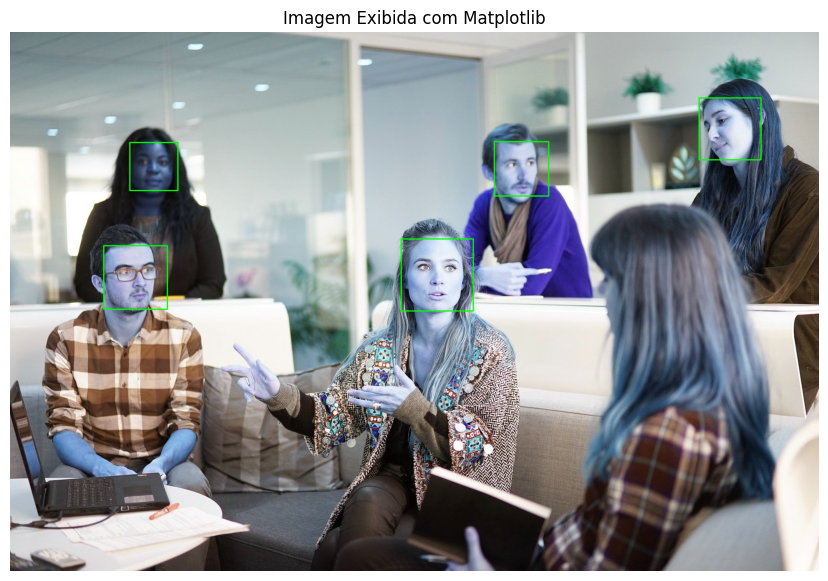

In [22]:
# aeessando cada uma das posições
for (x, y, l, a) in deteccoes2:
  #print(x, y, l, a)
  cv2.rectangle(imagem_2, (x, y), (x + l, y + a), (0,255,0), 2)
#cv2_imshow(imagem)

fig = plt.figure(figsize=(12, 7)) 
# detectar na imagem original
# 3. Exibir com Matplotlib
plt.imshow(imagem_2)
plt.title("Imagem Exibida com Matplotlib")
plt.axis('off') # Remove os eixos
plt.show()

In [23]:
# 2. Converter de BGR para RGB para cores corretas no Matplotlib
imagem_rgb_2 = cv2.cvtColor(imagem_2, cv2.COLOR_BGR2RGB)

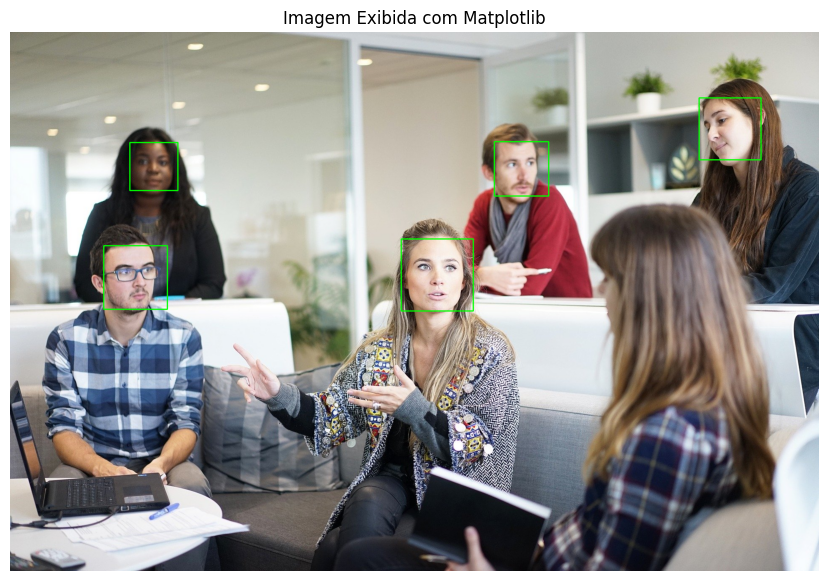

In [24]:
# aeessando cada uma das posições
for (x, y, l, a) in deteccoes2:
  #print(x, y, l, a)
  cv2.rectangle(imagem_rgb_2, (x, y), (x , y ), (0,255,0), 2)
#cv2_imshow(imagem)

fig = plt.figure(figsize=(12, 7)) 
# detectar na imagem original
# 3. Exibir com Matplotlib
plt.imshow(imagem_rgb_2)
plt.title("Imagem Exibida com Matplotlib")
plt.axis('off') # Remove os eixos
plt.show()